In [1]:
from photonic_annealing import PhotonicAnnealer
import os
import sys
sdk_install_path = r"C:\Program Files\HOLOEYE Photonics\SLM Display SDK (Python) v4.1.0"
python_api_path = os.path.join(sdk_install_path, "api", "python")

if python_api_path not in sys.path:
    sys.path.append(python_api_path)
    print(f"Added {python_api_path} to Python path.")

try:
    import HEDS
    from hedslib.heds_types import *
except ImportError:
    print(f"FATAL ERROR: Could not import HEDS library from {python_api_path}")
    print("Please verify the 'sdk_install_path' variable in this script.")
    sys.exit(1)

Added C:\Program Files\HOLOEYE Photonics\SLM Display SDK (Python) v4.1.0\api\python to Python path.


In [2]:
filename = 'MC100.npz'

def data_loader(filename):
    """
    Takes data from .npz and returns adjacency matrix.
    """
    import numpy as np
    import scipy.sparse as sp

    # Load the .npz file
    data = np.load(filename, allow_pickle=True)

    # Reconstruct the sparse adjacency matrix (CSR format)
    adj_sparse = sp.csr_matrix(
        (data['data'], data['indices'], data['indptr']),
        shape=tuple(data['shape'])
    )

    # If you want a dense NumPy array (e.g., for neural nets)
    return adj_sparse.toarray()

Adj = data_loader(filename)



In [3]:
import numpy as np

def generate_maxcut_graph(n_nodes):
    """
    Generates a random adjacency matrix for a max-cut graph with a given number of nodes.

    Args:
        n_nodes (int): The number of nodes in the graph.

    Returns:
        np.ndarray: A symmetric, 10x10 NumPy array representing the adjacency matrix.
    """
    # Create a random symmetric matrix with 0s and 1s
    rand_matrix = np.random.randint(0, 2, size=(n_nodes, n_nodes))
    
    # Ensure the matrix is symmetric
    adj_matrix = rand_matrix + rand_matrix.T
    
    # Set the diagonal to zero to remove self-loops
    np.fill_diagonal(adj_matrix, 0)
    
    # Ensure entries are only 0 or 1
    adj_matrix[adj_matrix > 1] = 1

    return adj_matrix

# Generate a random adjacency matrix for a 10-spin graph
graph_matrix = generate_maxcut_graph(10)

print(graph_matrix)


[[0 1 0 1 0 0 0 0 0 0]
 [1 0 1 0 0 0 1 1 1 1]
 [0 1 0 1 1 1 1 1 1 1]
 [1 0 1 0 1 1 0 1 1 1]
 [0 0 1 1 0 1 1 0 1 1]
 [0 0 1 1 1 0 0 1 0 1]
 [0 1 1 0 1 0 0 1 1 1]
 [0 1 1 1 0 1 1 0 1 1]
 [0 1 1 1 1 0 1 1 0 0]
 [0 1 1 1 1 1 1 1 0 0]]


In [4]:
test = PhotonicAnnealer(Adj, 100, 100)

Initializing Photonic Annealer...
Connecting to hardware...
SLM connected. Resolution: 1920 x 1080
Serial port COM21 opened at 115200 baud (timeout=0.001).
Preparing model (layout, compensation, eigendecomposition)...
  - SLM Layout: 10 rows x 10 cols
  - Macropixel Size: 192 x 108 pixels
Preparation complete.


Evaluating initial random spin configuration...
Initial energy: -0.3611 (eval time: 3.69s)

Current Temperature: 1000.0000
  Step 1/5 | New Energy Accepted: 0.7151
  Step 2/5 | New Energy Accepted: 0.2173
  Step 3/5 | New Energy Accepted: 0.7779
  Step 4/5 | New Energy Accepted: 1.0955
  Step 5/5 | New Energy Accepted: -0.5541
  Temp step took 22.90s

Current Temperature: 950.0000
  Step 1/5 | New Energy Accepted: -0.0710
  Step 2/5 | New Energy Accepted: 0.3108
  Step 3/5 | New Energy Accepted: 0.2724
  Step 4/5 | New Energy Accepted: -4.6531
  Step 5/5 | New Energy Accepted: -1.1156
  Temp step took 16.25s

Current Temperature: 902.5000
  Step 1/5 | New Energy Accepted: 2.4925
  Step 2/5 | New Energy Accepted: -0.2534
  Step 3/5 | New Energy Accepted: -3.2605
  Step 4/5 | New Energy Accepted: -1.0233
  Step 5/5 | New Energy Accepted: -1.1791
  Temp step took 15.52s

Current Temperature: 857.3750
  Step 1/5 | New Energy Accepted: 1.1214
  Step 2/5 | New Energy Accepted: -1.2343
  Step

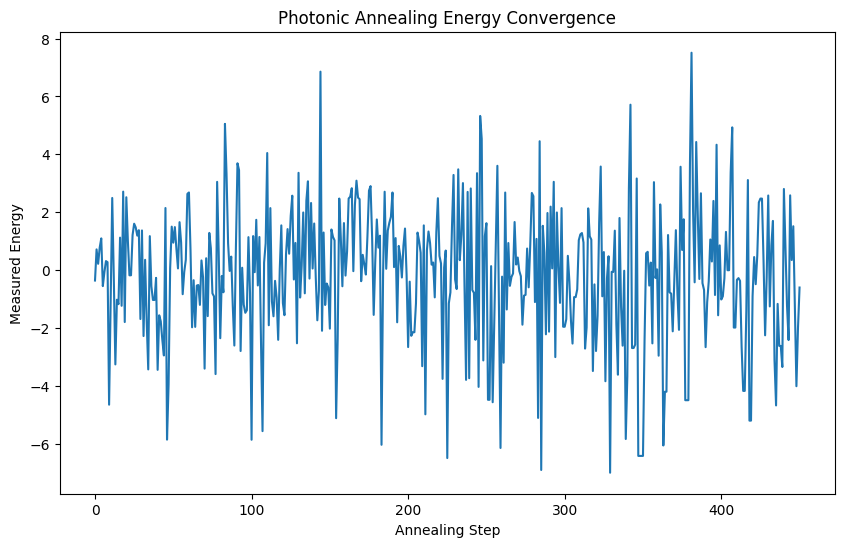

In [ ]:
# --- 3. Define Annealing Parameters ---
INITIAL_TEMP = 1000.0
FINAL_TEMP = 10
COOLING_RATE = 0.90
STEPS_PER_TEMP = 5 # Set low for testing, increase for real runs

import logging


final_spins, energy_data = test.run_annealing(
            initial_temp=INITIAL_TEMP,
            final_temp=FINAL_TEMP,
            cooling_rate=COOLING_RATE,
            steps_per_temp=STEPS_PER_TEMP
        )

In [6]:
print(energy_data)
copy_energy_data = energy_data.copy()

[-0.3610802404559408, 0.7150739679201434, 0.21729976139821439, 0.7778611595773217, 1.0955201698360781, -0.5541153238921304, -0.0709705309819526, 0.31077706455465304, 0.272435173710873, -4.65314841264003, -1.1155864620622378, 2.492515063415225, -0.25341818555184936, -3.2605215181374083, -1.0233392218941555, -1.1791058398791243, 1.121415650342076, -1.2343022338722989, 2.711794425069421, -1.7959213398792038, 2.5170074426349487, 0.9944556090752865, -0.18103290166233954, -0.17975755297815255, 1.2117931421106718, 1.6023548298541073, 1.4760627062414748, 1.1900474430903643, 1.3782096844379623, -1.6918660195203472, 1.3699974584305687, -2.2796603811863, 0.35484364043001637, -1.753673887319927, -3.4334867145602592, 1.172942714559829, -0.558777299113487, -1.0329951078832753, -1.0329951078832753, -0.2691737756453172, -3.4492090291390936, -1.563045703223163, -1.7703115494638428, -2.4134982504297824, -2.9513819777096764, 2.145239638780124, -5.861162152193584, -3.9531058336750107, 0.0710423865540335, 

In [7]:
for i in range(len(energy_data)):
    if i == len(energy_data) - 1:
        break
    if energy_data[i] < energy_data[i+1]:
        energy_data[i+1] = energy_data[i]

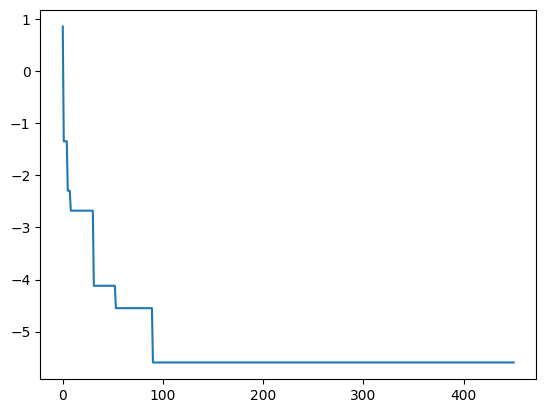

In [8]:
import matplotlib.pyplot as plt
plt.plot(energy_data)

In [8]:
print(final_spins)

[-1 -1 -1  1 -1  1 -1  1  1  1  1  1  1 -1  1  1 -1 -1 -1  1 -1  1  1  1
 -1  1  1  1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1  1  1  1 -1  1 -1  1  1  1  1
  1  1 -1 -1 -1  1 -1  1 -1  1  1  1 -1 -1  1  1 -1  1 -1 -1  1 -1 -1 -1
  1 -1 -1 -1  1 -1  1 -1 -1  1 -1 -1 -1 -1 -1 -1  1  1 -1  1  1 -1  1 -1
 -1  1 -1 -1]


In [9]:
def get_cut_value(adj_matrix, spins):
    """
    Calculates the value of a cut given an adjacency matrix and spin assignments.

    The cut value is the sum of weights of all edges that cross the partition.
    An edge (i, j) crosses the partition if node i and node j have different spins.

    Args:
        adj_matrix (list[list[float]] or np.ndarray): 
            A 2D list or NumPy array representing the weighted adjacency matrix 
            of the graph. adj_matrix[i][j] is the weight of the edge between 
            node i and node j. Assumed to be symmetric.
        
        spins (list[int] or np.ndarray): 
            A 1D list or array of spin assignments for each node.
            Typically +1 or -1, where +1 represents one partition and -1 
            represents the other. Must be the same length as the number of nodes.

    Returns:
        float: The total weight of the edges crossing the cut.
        
    Raises:
        ValueError: If the dimensions of the matrix and spin vector do not match.
    """
    
    num_nodes = len(adj_matrix)
    
    # --- Input Validation ---
    if num_nodes == 0:
        return 0
    if num_nodes != len(adj_matrix[0]):
        raise ValueError("Adjacency matrix must be square.")
    if num_nodes != len(spins):
        raise ValueError(f"Spin list length ({len(spins)}) must match the "
                         f"number of nodes ({num_nodes}).")

    cut_value = 0.0

    # Iterate over the upper triangle of the adjacency matrix
    # This ensures we count each edge (i, j) only once
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            
            edge_weight = adj_matrix[i][j]
            
            # Check if an edge exists
            if edge_weight > 0:
                # Check if the nodes are in different partitions (spins are different)
                if spins[i] != spins[j]:
                    # If they are, this edge crosses the cut. Add its weight.
                    cut_value += edge_weight
                    
    return cut_value
cut_value = get_cut_value(Adj, final_spins)
print(cut_value)

1266.0


In [3]:
import serial.tools.list_ports
print(list(serial.tools.list_ports.comports()))


[<serial.tools.list_ports_common.ListPortInfo object at 0x0000016BCD540580>, <serial.tools.list_ports_common.ListPortInfo object at 0x0000016BCD5409A0>, <serial.tools.list_ports_common.ListPortInfo object at 0x0000016BCD542260>, <serial.tools.list_ports_common.ListPortInfo object at 0x0000016BCD540F40>, <serial.tools.list_ports_common.ListPortInfo object at 0x0000016BCD540F10>, <serial.tools.list_ports_common.ListPortInfo object at 0x0000016BCD5423E0>, <serial.tools.list_ports_common.ListPortInfo object at 0x0000016BCD541F00>, <serial.tools.list_ports_common.ListPortInfo object at 0x0000016BCD541C30>, <serial.tools.list_ports_common.ListPortInfo object at 0x0000016BCD541E70>, <serial.tools.list_ports_common.ListPortInfo object at 0x0000016BCD541EA0>, <serial.tools.list_ports_common.ListPortInfo object at 0x0000016BCD542200>, <serial.tools.list_ports_common.ListPortInfo object at 0x0000016BCD5423B0>, <serial.tools.list_ports_common.ListPortInfo object at 0x0000016BCD5426E0>, <serial.too

In [6]:
slm = HEDS.SLM.Init()
print("SLM methods:", sorted([m for m in dir(slm) if not m.startswith('_')]))


SLM methods: ['Init', 'ZernikePrintString', 'errorCode', 'frametime_ms', 'getWavelength', 'getWavelengths', 'height_mm', 'height_px', 'id', 'loadAxicon', 'loadBlankScreen', 'loadCGHFromImageData', 'loadCGHFromImageFile', 'loadDividedScreenHorizontal', 'loadDividedScreenVertical', 'loadGratingBinaryBlazeHorizontal', 'loadGratingBinaryVertical', 'loadGratingBlazeHorizontal', 'loadGratingBlazeVertical', 'loadImageData', 'loadImageDataFromFile', 'loadPhaseData', 'loadPhaseDataFromFile', 'loadPhaseFunctionAxicon', 'loadPhaseFunctionLens', 'loadPhaseFunctionVortex', 'loadVortex', 'pixelsize_um', 'preview', 'refreshrate_hz', 'setChromaticAbberationFactorsCFS', 'setWavelength', 'setWavelengthCFS', 'showAxicon', 'showBlankScreen', 'showCGHFromImageData', 'showCGHFromImageFile', 'showDividedScreenHorizontal', 'showDividedScreenVertical', 'showGratingBinaryHorizontal', 'showGratingBinaryVertical', 'showGratingBlazeHorizontal', 'showGratingBlazeVertical', 'showImageData', 'showImageDataFromFile', 

In [7]:
# create a tiny dummy buffer to get a data handle (one-time)
buf = (np.zeros((16,16), dtype=np.float32))
dh = slm.loadPhaseData(buf)
print("DataHandle type:", type(dh))
print("DataHandle methods:", sorted([m for m in dir(dh) if not m.startswith('_')]))
# optionally print constants from HEDS that look relevant:
print("HEDSDHST_* states:", [n for n in dir(HEDS) if n.startswith('HEDSDHST_')])
print("Data type constants:", [n for n in dir(HEDS) if 'DT_' in n or 'U8' in n or 'INT' in n])


DataHandle type: <class 'tuple'>
DataHandle methods: ['count', 'index']
HEDSDHST_* states: ['HEDSDHST_ConvertingData', 'HEDSDHST_Error', 'HEDSDHST_Finished', 'HEDSDHST_Issued', 'HEDSDHST_LoadingFile', 'HEDSDHST_ProcessingData', 'HEDSDHST_ReadyToRender', 'HEDSDHST_Rendering', 'HEDSDHST_TransferringData', 'HEDSDHST_Visible', 'HEDSDHST_VisibleDurationFinished', 'HEDSDHST_WaitingForProcessing', 'HEDSDHST_WaitingForRendering', 'HEDSDHST_WaitingForTransfer', 'HEDSDHST_WaitingToBecomeVisible']
Data type constants: ['HEDSDTFMT_INT_RGB24', 'HEDSDTFMT_INT_RGBA32', 'HEDSDTFMT_INT_U8', 'POINTER']


In [8]:
def bench_paths(slm, H, W):
    import numpy as np, time
    f32 = np.zeros((H,W), dtype=np.float32)
    u8  = np.zeros((H,W), dtype=np.uint8)
    # fill some nontrivial pattern
    f32[:] = np.random.rand(H,W).astype(np.float32) * 2*np.pi
    scale = 255.0/(2*np.pi)
    tmp = np.empty_like(f32)
    # float32 show
    t0=time.perf_counter(); err=slm.showPhaseData(f32); t1=time.perf_counter()
    print("show float32 time:", t1-t0, "err:", err)
    # uint8 convert + show
    t0=time.perf_counter(); np.multiply(f32, scale, out=tmp); np.rint(tmp, out=tmp); u8[:] = tmp.astype(np.uint8, copy=False); err=slm.showPhaseData(u8); t1=time.perf_counter()
    print("convert+show uint8 time:", t1-t0, "err:", err)
    # loadPhaseData + show + wait (if available)
    try:
        t0=time.perf_counter(); res=slm.loadPhaseData(u8); t1=time.perf_counter()
        print("loadPhaseData time:", t1-t0, "res:", type(res))
        # show using returned handle if possible
        try:
            err = slm.showPhaseData(res)
        except Exception:
            err = slm.showPhaseData(u8)
        t2=time.perf_counter()
        print("show after load time:", t2-t1, "err:", err)
    except Exception as e:
        print("loadPhaseData path failed:", e)


In [9]:
bench_paths(slm, 1080, 1920)

show float32 time: 0.06736669999736478 err: 0
convert+show uint8 time: 0.03380549999928917 err: 0
loadPhaseData time: 0.001869200001237914 res: <class 'tuple'>
show after load time: 0.0488597999974445 err: 0
